# Week 3 - Exercises

## Exercise 1: Collecting Research Articles from IC2S2 Authors

In [1]:
import pandas as pd

ic2s2_authors = pd.read_csv("week2_openalex_authors.csv")
print(f"total authors: {len(ic2s2_authors)}")
print(ic2s2_authors['works_count'].describe())

total authors: 1297
count    1297.000000
mean      111.066307
std       199.614896
min         1.000000
25%        13.000000
50%        46.000000
75%       127.000000
max      2790.000000
Name: works_count, dtype: float64


In [2]:
# filter authors: works_count between 5 and 5000
ic2s2_authors = ic2s2_authors[(ic2s2_authors['works_count'] >= 5) & (ic2s2_authors['works_count'] <= 5000)]
print(f"authors after filtering: {len(ic2s2_authors)}")

authors after filtering: 1141


In [3]:
import requests

api_key = "zhj01t4KDUqWAHNFrcZrok"

# test with one author
sample_id = ic2s2_authors['openalex_id'].iloc[1]  # Aaron Nichols
print(f"testing with: {sample_id}")

response = requests.get(
    "https://api.openalex.org/works",
    params={
        "api_key": api_key,
        "filter": f"author.id:{sample_id}",
        "per_page": 1
    }
)

data = response.json()
print(f"total works for this author: {data['meta']['count']}")
print(f"cost of this call: ${data['meta']['cost_usd']}")

testing with: https://openalex.org/A5089395967
total works for this author: 10
cost of this call: $0.0001


In [4]:
# inspect the structure of one work
work = data['results'][0]
print(work.keys())

dict_keys(['id', 'doi', 'title', 'display_name', 'publication_year', 'publication_date', 'ids', 'language', 'primary_location', 'type', 'indexed_in', 'open_access', 'authorships', 'institutions', 'countries_distinct_count', 'institutions_distinct_count', 'corresponding_author_ids', 'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci', 'has_fulltext', 'cited_by_count', 'citation_normalized_percentile', 'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext', 'is_xpac', 'primary_topic', 'topics', 'keywords', 'concepts', 'mesh', 'locations_count', 'locations', 'best_oa_location', 'sustainable_development_goals', 'awards', 'funders', 'has_content', 'content_urls', 'referenced_works_count', 'referenced_works', 'related_works', 'abstract_inverted_index', 'counts_by_year', 'updated_date', 'created_date'])


In [5]:
# inspect the fields we need to extract
print("id:", work['id'])
print("publication_year:", work['publication_year'])
print("cited_by_count:", work['cited_by_count'])
print("title:", work['title'])
print()
# authorships is a list — let's see what one entry looks like
print("authorships (first entry):", work['authorships'][0])
print()
# abstract is an inverted index — let's peek at it
print("abstract_inverted_index (first 3 items):", dict(list(work['abstract_inverted_index'].items())[:3]) if work['abstract_inverted_index'] else "None")

id: https://openalex.org/W2408628302
publication_year: 2016
cited_by_count: 61
title: Music As a Sacred Cue? Effects of Religious Music on Moral Behavior

authorships (first entry): {'author_position': 'first', 'author': {'id': 'https://openalex.org/A5048616798', 'display_name': 'Martin Lang', 'orcid': 'https://orcid.org/0000-0002-2231-1059'}, 'institutions': [{'id': 'https://openalex.org/I21449261', 'display_name': 'Masaryk University', 'ror': 'https://ror.org/02j46qs45', 'country_code': 'CZ', 'type': 'education', 'lineage': ['https://openalex.org/I21449261']}, {'id': 'https://openalex.org/I140172145', 'display_name': 'University of Connecticut', 'ror': 'https://ror.org/02der9h97', 'country_code': 'US', 'type': 'education', 'lineage': ['https://openalex.org/I140172145']}], 'countries': ['CZ', 'US'], 'is_corresponding': True, 'raw_author_name': 'Martin Lang', 'raw_affiliation_strings': ['Department of Anthropology, University of ConnecticutStorrs, CT, USA; LEVYNA Laboratory for the Exp

In [6]:
# extract author ids from the authorships list
author_ids = [a['author']['id'] for a in work['authorships']]
print(f"number of authors: {len(author_ids)}")
print(author_ids)

number of authors: 6
['https://openalex.org/A5048616798', 'https://openalex.org/A5018921866', 'https://openalex.org/A5034964074', 'https://openalex.org/A5089395967', 'https://openalex.org/A5109388873', 'https://openalex.org/A5016308056']


In [7]:
# test with citation filter added
response = requests.get(
    "https://api.openalex.org/works",
    params={
        "api_key": api_key,
        "filter": f"author.id:{sample_id},cited_by_count:>10",
        "per_page": 1
    }
)

data = response.json()
print(f"works with >10 citations: {data['meta']['count']} (out of 10 total)")

works with >10 citations: 2 (out of 10 total)


In [8]:
# let's look up the concept IDs we need
# we can use the OpenAlex concepts endpoint
concepts_to_find = ["Sociology", "Psychology", "Economics", "Political Science", 
                     "Mathematics", "Physics", "Computer Science"]

for c in concepts_to_find:
    r = requests.get(
        "https://api.openalex.org/concepts",
        params={"api_key": api_key, "filter": f"display_name.search:{c},level:0"}
    )
    results = r.json()['results']
    if results:
        print(f"{c}: {results[0]['id']}")
    else:
        print(f"{c}: NOT FOUND")

Sociology: https://openalex.org/C144024400
Psychology: https://openalex.org/C15744967
Economics: https://openalex.org/C162324750
Political Science: https://openalex.org/C17744445
Mathematics: https://openalex.org/C33923547
Physics: https://openalex.org/C121332964
Computer Science: https://openalex.org/C41008148


In [9]:
# define concept ID groups (just the short IDs work too)
social = "C144024400|C15744967|C162324750|C17744445"
quant = "C33923547|C121332964|C41008148"

# test the full filter on our sample author
response = requests.get(
    "https://api.openalex.org/works",
    params={
        "api_key": api_key,
        "filter": f"author.id:{sample_id},cited_by_count:>10,concepts.id:{social},concepts.id:{quant}",
        "per_page": 1
    }
)

data = response.json()
print(f"works matching all filters: {data['meta']['count']} (out of 10 total)")

works matching all filters: 0 (out of 10 total)


In [10]:
# test with a different author — pick someone more likely to be in CSS
# let's find someone with a high h_index, more likely to be a known CSS researcher
top_authors = ic2s2_authors.nlargest(5, 'h_index')[['display_name', 'openalex_id', 'h_index']]
print(top_authors)

      display_name                       openalex_id  h_index
570  Jian‐Kang Zhu  https://openalex.org/A5049293054      190
823   Michaël Maes  https://openalex.org/A5032880777      141
995    Robert West  https://openalex.org/A5059645286      132
498   Chunhua Shen  https://openalex.org/A5006294869      122
32   Alex Pentland  https://openalex.org/A5007176508      121


In [11]:
# test with Alex Pentland
pentland_id = "https://openalex.org/A5007176508"

response = requests.get(
    "https://api.openalex.org/works",
    params={
        "api_key": api_key,
        "filter": f"author.id:{pentland_id},cited_by_count:>10,concepts.id:{social},concepts.id:{quant}",
        "per_page": 1
    }
)

data = response.json()
print(f"Pentland works matching all filters: {data['meta']['count']}")

Pentland works matching all filters: 252


In [12]:
# let's estimate how many API calls we'll need
# first, check total works across ALL authors with our filters
# we can batch author IDs with | (OR) — let's test with a small batch

batch = ic2s2_authors['openalex_id'].iloc[:25]
author_filter = "|".join(batch.values)

response = requests.get(
    "https://api.openalex.org/works",
    params={
        "api_key": api_key,
        "filter": f"author.id:{author_filter},cited_by_count:>10,concepts.id:{social},concepts.id:{quant}",
        "per_page": 1
    }
)

data = response.json()
print(f"works from first 25 authors: {data['meta']['count']}")
print(f"cost of this call: ${data['meta']['cost_usd']}")

works from first 25 authors: 290
cost of this call: $0.0001


In [13]:
# rough estimate:
# 1141 authors / 25 per batch = ~46 batches
# each batch returns ~290 works on average (probably varies a lot)
# but let's get a better estimate — check total works for all authors

import math

n_batches = math.ceil(len(ic2s2_authors) / 25)
print(f"number of batches: {n_batches}")

# estimated total works (rough): 290 works per 25 authors
est_total_works = (len(ic2s2_authors) / 25) * 290
est_pages = est_total_works / 100  # 100 results per page
est_calls = n_batches + est_pages  # batch calls + pagination calls
est_cost = est_calls * 0.0001

print(f"estimated total works: {est_total_works:.0f}")
print(f"estimated total API calls: {est_calls:.0f}")
print(f"estimated cost: ${est_cost:.2f}")

number of batches: 46
estimated total works: 13236
estimated total API calls: 178
estimated cost: $0.02


In [14]:
# let's first write a function to fetch all works for a batch of author IDs
# using cursor paging as recommended by the exercise

def fetch_works_for_batch(author_ids, api_key, social, quant):
    """Fetch all works for a batch of authors, handling pagination with cursor."""
    all_works = []
    author_filter = "|".join(author_ids)
    cursor = "*"  # initial cursor value
    
    while cursor:
        response = requests.get(
            "https://api.openalex.org/works",
            params={
                "api_key": api_key,
                "filter": f"author.id:{author_filter},cited_by_count:>10,concepts.id:{social},concepts.id:{quant}",
                "per_page": 100,
                "cursor": cursor
            }
        )
        data = response.json()
        results = data.get('results', [])
        all_works.extend(results)
        
        # get next cursor — None means we've reached the end
        cursor = data['meta'].get('next_cursor')
    
    return all_works

# test it on our first batch of 25
batch = ic2s2_authors['openalex_id'].iloc[:25].values
works = fetch_works_for_batch(batch, api_key, social, quant)
print(f"fetched {len(works)} works from first batch")

fetched 290 works from first batch


In [15]:
from tqdm import tqdm
from joblib import Parallel, delayed

# split all author IDs into batches of 25
all_ids = ic2s2_authors['openalex_id'].values
batches = [all_ids[i:i+25] for i in range(0, len(all_ids), 25)]
print(f"total batches: {len(batches)}")

# fetch all works in parallel using 5 cores
all_works_nested = Parallel(n_jobs=5)(
    delayed(fetch_works_for_batch)(batch, api_key, social, quant)
    for batch in tqdm(batches)
)

# flatten the list of lists into one list
all_works = [w for batch_works in all_works_nested for w in batch_works]
print(f"total works after proper flattening: {len(all_works)}")

# check uniqueness
unique_ids = set(w['id'] for w in all_works)
print(f"unique works: {len(unique_ids)}")

total batches: 46


100%|██████████| 46/46 [00:52<00:00,  1.13s/it]


total works after proper flattening: 15657
unique works: 13884


In [16]:
# extract the fields we need, filtering out works with 10+ authors
papers = []
abstracts = []

for w in all_works:
    author_ids = [a['author']['id'] for a in w['authorships']]
    
    # skip works with 10 or more authors
    if len(author_ids) >= 10:
        continue
    
    papers.append({
        'id': w['id'],
        'publication_year': w['publication_year'],
        'cited_by_count': w['cited_by_count'],
        'author_ids': author_ids
    })
    
    abstracts.append({
        'id': w['id'],
        'title': w['title'],
        'abstract_inverted_index': w['abstract_inverted_index']
    })

print(f"works after filtering <10 authors: {len(papers)} (removed {len(all_works) - len(papers)})")

works after filtering <10 authors: 14489 (removed 1168)


In [17]:
df_papers = pd.DataFrame(papers)
df_abstracts = pd.DataFrame(abstracts)

print(f"D2 - IC2S2 papers: {df_papers.shape}")
print(f"D3 - IC2S2 abstracts: {df_abstracts.shape}")
print()
print(df_papers.head())

D2 - IC2S2 papers: (14489, 4)
D3 - IC2S2 abstracts: (14489, 3)

                                 id  publication_year  cited_by_count  \
0  https://openalex.org/W2047940964            2004.0            7334   
1  https://openalex.org/W3103362336            2018.0            6724   
2  https://openalex.org/W2157082398            2008.0            2163   
3  https://openalex.org/W2974087526            2019.0            1732   
4  https://openalex.org/W3133423348            2021.0            1712   

                                          author_ids  
0  [https://openalex.org/A5014647140, https://ope...  
1  [https://openalex.org/A5014647140, https://ope...  
2  [https://openalex.org/A5014647140, https://ope...  
3  [https://openalex.org/A5054642819, https://ope...  
4  [https://openalex.org/A5076143079, https://ope...  


In [18]:
# drop duplicate works
df_papers = df_papers.drop_duplicates(subset='id')
df_abstracts = df_abstracts.drop_duplicates(subset='id')

print(f"D2 - IC2S2 papers after dedup: {df_papers.shape}")
print(f"D3 - IC2S2 abstracts after dedup: {df_abstracts.shape}")

D2 - IC2S2 papers after dedup: (12991, 4)
D3 - IC2S2 abstracts after dedup: (12991, 3)


In [19]:
df_papers.to_json("week3_ic2s2_papers.json", orient='records')
df_abstracts.to_json("week3_ic2s2_abstracts.json", orient='records')

print("D2 saved to week3_ic2s2_papers.json")
print("D3 saved to week3_ic2s2_abstracts.json")

D2 saved to week3_ic2s2_papers.json
D3 saved to week3_ic2s2_abstracts.json


In [20]:
# count unique researchers across all papers
all_author_ids = set()
for ids in df_papers['author_ids']:
    all_author_ids.update(ids)

print(f"unique works: {len(df_papers)}")
print(f"unique researchers who co-authored these works: {len(all_author_ids)}")

unique works: 12991
unique researchers who co-authored these works: 20001


### Data Overview and Reflection Questions

**Dataset summary.**
the ic2s2 papers dataset (D2) contains 12,991 unique works. across these works, there are 20,001 unique researchers who have co-authored at least one paper.

**Efficiency in code.**
we used several strategies to speed up data collection. first, we batched 25 author IDs per API request using the OR filter syntax, reducing ~1,141 individual calls to just 46. second, we applied filters directly in the API call (cited_by_count >10, concept filters for social science + quantitative fields) so only relevant works were returned. third, we set per_page=100 to minimize pagination calls. finally, we used joblib's Parallel with 5 cores to run batches simultaneously. combined, these brought total fetch time down to about 1 minute.

**Filtering criteria and dataset relevance.**
the filters help keep the dataset focused on established, interdisciplinary css research, but they introduce biases. the >10 citations threshold excludes recent work that hasn't had time to accumulate citations, underrepresenting emerging topics and early-career researchers. the concept filter requiring both a social science and a quantitative field excludes qualitative css work like computational ethnography. the <10 authors filter removes large collaborative projects, which are increasingly common. the works_count 5–5000 filter removes very inactive researchers but also potentially excludes newcomers. overall, the dataset skews toward well-established, quantitative, small-team research.

## Exercise 2: Collecting Data from IC2S2 Co-Authors

In [21]:
import pandas as pd
import json

# load D1 (IC2S2 authors) and D2 (IC2S2 papers)
ic2s2_authors = pd.read_csv("week2_openalex_authors.csv")
ic2s2_authors = ic2s2_authors[(ic2s2_authors['works_count'] >= 5) & (ic2s2_authors['works_count'] <= 5000)]

df_papers = pd.read_json("week3_ic2s2_papers.json")

# get all unique author IDs from D2
all_author_ids = set()
for ids in df_papers['author_ids']:
    all_author_ids.update(ids)

# remove IC2S2 authors — these are the co-authors we need to fetch
ic2s2_ids = set(ic2s2_authors['openalex_id'].values)
coauthor_ids = all_author_ids - ic2s2_ids

print(f"total unique authors in D2: {len(all_author_ids)}")
print(f"IC2S2 authors (already have): {len(ic2s2_ids)}")
print(f"co-authors to fetch: {len(coauthor_ids)}")

total unique authors in D2: 20001
IC2S2 authors (already have): 1136
co-authors to fetch: 19100


In [22]:
import math

# Step 1: Fetch author info (D4)
# We can batch up to 100 IDs using the filter endpoint
step1_batches = math.ceil(len(coauthor_ids) / 100)
step1_cost = step1_batches * 0.0001

# Step 2: Fetch works (D5, D6) — same as Exercise 1 but more authors
# 25 authors per batch
step2_batches = math.ceil(len(coauthor_ids) / 25)
# rough estimate: assume similar ratio of works per author as Exercise 1
works_per_author = len(df_papers) / len(ic2s2_ids)
est_works = len(coauthor_ids) * works_per_author
est_pages = est_works / 100
step2_cost = (step2_batches + est_pages) * 0.0001

print(f"--- Step 1: Author info ---")
print(f"batches: {step1_batches}")
print(f"estimated cost: ${step1_cost:.2f}")
print()
print(f"--- Step 2: Co-author works ---")
print(f"batches: {step2_batches}")
print(f"estimated works: {est_works:.0f}")
print(f"estimated cost: ${step2_cost:.2f}")
print()
print(f"total estimated cost: ${step1_cost + step2_cost:.2f}")

--- Step 1: Author info ---
batches: 191
estimated cost: $0.02

--- Step 2: Co-author works ---
batches: 764
estimated works: 218423
estimated cost: $0.29

total estimated cost: $0.31


In [23]:
import requests

# test fetching author info for a small batch
test_ids = list(coauthor_ids)[:5]
author_filter = "|".join(test_ids)

response = requests.get(
    "https://api.openalex.org/authors",
    params={
        "api_key": api_key,
        "filter": f"id:{author_filter}",
        "select": "id,display_name,works_api_url,summary_stats,last_known_institutions,works_count",
        "per_page": 100
    }
)

data = response.json()
print(f"returned: {data['meta']['count']} authors")
print(f"cost: ${data['meta']['cost_usd']}")
print()
# inspect one result
a = data['results'][0]
print(f"id: {a['id']}")
print(f"display_name: {a['display_name']}")
print(f"works_count: {a['works_count']}")
print(f"h_index: {a['summary_stats']['h_index']}")
insts = a.get('last_known_institutions') or []
print(f"country_code: {insts[0]['country_code'] if insts else None}")

returned: 5 authors
cost: $0.0001

id: https://openalex.org/A5042260991
display_name: Jukka K. Nurminen
works_count: 208
h_index: 28
country_code: FI


In [24]:
# remove any None values from coauthor IDs
coauthor_ids = {x for x in coauthor_ids if x is not None}
print(f"co-authors after removing None: {len(coauthor_ids)}")

# rebuild batches
coauthor_list = list(coauthor_ids)
batches = [coauthor_list[i:i+100] for i in range(0, len(coauthor_list), 100)]
print(f"total batches: {len(batches)}")

co-authors after removing None: 19099
total batches: 191


In [25]:
import time

def fetch_authors_batch(author_ids, api_key):
    """fetch author info for a batch of IDs."""
    author_filter = "|".join(author_ids)
    
    for attempt in range(3):
        try:
            response = requests.get(
                "https://api.openalex.org/authors",
                params={
                    "api_key": api_key,
                    "filter": f"id:{author_filter}",
                    "select": "id,display_name,works_api_url,summary_stats,last_known_institutions,works_count",
                    "per_page": 50
                }
            )
            return response.json().get('results', [])
        except Exception:
            time.sleep(1 * (attempt + 1))
    
    return []

batches = [coauthor_list[i:i+50] for i in range(0, len(coauthor_list), 50)]
print(f"total batches: {len(batches)}")

all_coauthors_nested = Parallel(n_jobs=5, verbose=5)(
    delayed(fetch_authors_batch)(batch, api_key)
    for batch in batches
)

all_coauthors = [a for batch in all_coauthors_nested if batch for a in batch]
print(f"total co-authors fetched: {len(all_coauthors)}")

total batches: 382


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=5)]: Done  62 tasks      | elapsed:    7.0s
[Parallel(n_jobs=5)]: Done 152 tasks      | elapsed:   16.7s
[Parallel(n_jobs=5)]: Done 278 tasks      | elapsed:   30.0s


total co-authors fetched: 19099


[Parallel(n_jobs=5)]: Done 382 out of 382 | elapsed:   40.9s finished


In [26]:
# build D4 - IC2S2 co-authors
coauthor_rows = []
for a in all_coauthors:
    summary = a.get('summary_stats') or {}
    insts = a.get('last_known_institutions') or []
    
    coauthor_rows.append({
        'id': a['id'],
        'display_name': a['display_name'],
        'works_api_url': a['works_api_url'],
        'h_index': summary.get('h_index'),
        'works_count': a['works_count'],
        'country_code': insts[0]['country_code'] if insts else None
    })

df_coauthors = pd.DataFrame(coauthor_rows)
print(f"D4 - IC2S2 co-authors: {len(df_coauthors)}")
print(df_coauthors.head())

D4 - IC2S2 co-authors: 19099
                                 id           display_name  \
0  https://openalex.org/A5087631107         Alan J. Heeger   
1  https://openalex.org/A5064087878      Shinichi Nakagawa   
2  https://openalex.org/A5105457488  Françesco Della Corte   
3  https://openalex.org/A5012965551    Daniel Gática-Pérez   
4  https://openalex.org/A5089095204            Karen Stein   

                                       works_api_url  h_index  works_count  \
0  https://api.openalex.org/works?filter=author.i...      179         1108   
1  https://api.openalex.org/works?filter=author.i...       94          756   
2  https://api.openalex.org/works?filter=author.i...       51          431   
3  https://api.openalex.org/works?filter=author.i...       64          385   
4  https://api.openalex.org/works?filter=author.i...       30          333   

  country_code  
0          NaN  
1           JP  
2           IT  
3           CH  
4           US  


In [27]:
df_coauthors = df_coauthors[(df_coauthors['works_count'] >= 5) & (df_coauthors['works_count'] <= 5000)]
print(f"D4 after filtering: {len(df_coauthors)}")

df_coauthors.to_json("week3_ic2s2_coauthors.json", orient='records')
print("D4 saved to week3_ic2s2_coauthors.json")

D4 after filtering: 17414
D4 saved to week3_ic2s2_coauthors.json


In [28]:
print(f"co-authors to fetch works for: {len(df_coauthors)}")

# estimate cost
import math
n_batches = math.ceil(len(df_coauthors) / 25)
print(f"batches of 25: {n_batches}")
print(f"estimated cost: ${n_batches * 0.0001:.2f} (just the initial calls, plus pagination)")

co-authors to fetch works for: 17414
batches of 25: 697
estimated cost: $0.07 (just the initial calls, plus pagination)


In [29]:
coauthor_ids_for_works = df_coauthors['id'].values
batches_works = [coauthor_ids_for_works[i:i+25] for i in range(0, len(coauthor_ids_for_works), 25)]
print(f"total batches: {len(batches_works)}")

all_coauthor_works_nested = Parallel(n_jobs=5, verbose=3)(
    delayed(fetch_works_for_batch)(batch, api_key, social, quant)
    for batch in batches_works
)

all_coauthor_works = [w for batch_works in all_coauthor_works_nested if batch_works for w in batch_works]
print(f"total co-author works fetched: {len(all_coauthor_works)}")

unique_coauthor_work_ids = set(w['id'] for w in all_coauthor_works)
print(f"unique co-author works: {len(unique_coauthor_work_ids)}")

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


total batches: 697


[Parallel(n_jobs=5)]: Done  22 tasks      | elapsed:   43.3s
[Parallel(n_jobs=5)]: Done 118 tasks      | elapsed:  3.5min
[Parallel(n_jobs=5)]: Done 278 tasks      | elapsed:  8.6min
[Parallel(n_jobs=5)]: Done 502 tasks      | elapsed: 15.3min
[Parallel(n_jobs=5)]: Done 697 out of 697 | elapsed: 26.4min finished


total co-author works fetched: 319490
unique co-author works: 243599


In [ ]:
# extract fields, filter <10 authors, and build D5 and D6
# also: only keep author_ids that are IC2S2 authors or co-authors
valid_author_ids = set(ic2s2_authors['openalex_id'].values) | set(df_coauthors['id'].values)

coauthor_papers = []
coauthor_abstracts = []

for w in all_coauthor_works:
    author_ids = [a['author']['id'] for a in w['authorships']]
    
    if len(author_ids) >= 10:
        continue
    
    # filter author_ids to only include IC2S2 authors or co-authors
    filtered_author_ids = [aid for aid in author_ids if aid in valid_author_ids]
    
    coauthor_papers.append({
        'id': w['id'],
        'publication_year': w['publication_year'],
        'cited_by_count': w['cited_by_count'],
        'author_ids': filtered_author_ids
    })
    
    coauthor_abstracts.append({
        'id': w['id'],
        'title': w['title'],
        'abstract_inverted_index': w['abstract_inverted_index']
    })

df_coauthor_papers = pd.DataFrame(coauthor_papers).drop_duplicates(subset='id')
df_coauthor_abstracts = pd.DataFrame(coauthor_abstracts).drop_duplicates(subset='id')

print(f"D5 - co-author papers: {len(df_coauthor_papers)}")
print(f"D6 - co-author abstracts: {len(df_coauthor_abstracts)}")

D5 - co-author papers: 229759
D6 - co-author abstracts: 229759


In [31]:
# combine D1 + D4 → CSS Authors
df_ic2s2_authors_slim = ic2s2_authors[['openalex_id', 'display_name', 'works_api_url', 'h_index', 'works_count', 'country_code']].rename(columns={'openalex_id': 'id'})
css_authors = pd.concat([df_ic2s2_authors_slim, df_coauthors], ignore_index=True).drop_duplicates(subset='id')

# combine D2 + D5 → CSS Papers, then remove single-author papers
css_papers = pd.concat([df_papers, df_coauthor_papers], ignore_index=True).drop_duplicates(subset='id')
css_papers = css_papers[css_papers['author_ids'].apply(len) > 1]

# combine D3 + D6 → CSS Abstracts
css_abstracts = pd.concat([df_abstracts, df_coauthor_abstracts], ignore_index=True).drop_duplicates(subset='id')

print(f"CSS Authors: {len(css_authors)}")
print(f"CSS Papers: {len(css_papers)}")
print(f"CSS Abstracts: {len(css_abstracts)}")

CSS Authors: 18550
CSS Papers: 47713
CSS Abstracts: 230814


In [32]:
# make sure abstracts only include papers that are in CSS Papers
css_abstracts = css_abstracts[css_abstracts['id'].isin(css_papers['id'])]

# final check
print(f"CSS Authors: {len(css_authors)}")
print(f"CSS Papers: {len(css_papers)}")
print(f"CSS Abstracts: {len(css_abstracts)}")

# verify no duplicates
print(f"\nduplicates check:")
print(f"  authors: {css_authors['id'].duplicated().sum()}")
print(f"  papers: {css_papers['id'].duplicated().sum()}")
print(f"  abstracts: {css_abstracts['id'].duplicated().sum()}")

CSS Authors: 18550
CSS Papers: 47713
CSS Abstracts: 47713

duplicates check:
  authors: 0
  papers: 0
  abstracts: 0


In [33]:
css_authors.to_json("week3_css_authors.json", orient='records')
css_papers.to_json("week3_css_papers.json", orient='records')
css_abstracts.to_json("week3_css_abstracts.json", orient='records')

print("CSS Authors saved to week3_css_authors.json")
print("CSS Papers saved to week3_css_papers.json")
print("CSS Abstracts saved to week3_css_abstracts.json")

CSS Authors saved to week3_css_authors.json
CSS Papers saved to week3_css_papers.json
CSS Abstracts saved to week3_css_abstracts.json


In [34]:
# filter D2 author_ids too
valid_author_ids = set(css_authors['id'].values)

css_papers['author_ids'] = css_papers['author_ids'].apply(
    lambda ids: [aid for aid in ids if aid in valid_author_ids]
)

# re-filter single-author papers (some might now have only 1 after filtering)
css_papers = css_papers[css_papers['author_ids'].apply(len) > 1]
css_abstracts = css_abstracts[css_abstracts['id'].isin(css_papers['id'])]

print(f"CSS Papers after re-filtering: {len(css_papers)}")
print(f"CSS Abstracts after re-filtering: {len(css_abstracts)}")

CSS Papers after re-filtering: 47599
CSS Abstracts after re-filtering: 47599


In [35]:
css_papers.to_json("week3_css_papers.json", orient='records')
css_abstracts.to_json("week3_css_abstracts.json", orient='records')

print("updated files saved")

updated files saved


## Exercise 3: Data Overview and Reflection Questions

**Dataset summary.**
the final css authors dataset contains 18,550 researchers, the css papers dataset contains 47,599 collaborative works, and the css abstracts dataset contains 47,599 entries. the authors dataset combines 1,141 ic2s2 authors with 17,409 co-authors identified through snowball sampling.

**Efficiency in code.**
we reused the same fetch function and filtering logic from exercise 1, adapting it for the larger co-author dataset. for fetching author info (D4), we batched 50 IDs per request and parallelized with 5 cores using joblib, completing 19,099 lookups in about 40 seconds. for fetching works (D5/D6), we batched 25 authors per request with cursor paging and the same parallel setup, completing in about 26 minutes. we also added retry logic with backoff to handle rate limit errors gracefully. one improvement would have been to exclude ic2s2 author works from the co-author query to avoid fetching duplicates.

**Reflection.**
filtering author_ids to only include ic2s2 authors or co-authors ensures the dataset represents a closed, well-defined network. without this filter, the papers would reference thousands of external collaborators we have no information about — no name, no h-index, no country. this would make the co-authorship network incomplete and misleading, since edges would point to unknown nodes. by restricting to known authors, we ensure every person in the network has associated metadata, making downstream analysis (like building co-authorship graphs or computing centrality measures) meaningful and consistent.

## Exercise 4: Analyzing Author Citations

### Task 1: Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

css_authors = pd.read_json("week3_css_authors.json")
css_papers = pd.read_json("week3_css_papers.json")

print(f"authors: {len(css_authors)}")
print(f"papers: {len(css_papers)}")

authors: 18550
papers: 47599


In [38]:
# for each paper, credit cited_by_count to each author
author_citations = {}

for _, row in css_papers.iterrows():
    for aid in row['author_ids']:
        author_citations[aid] = author_citations.get(aid, 0) + row['cited_by_count']

# merge into css_authors
css_authors['total_citations'] = css_authors['id'].map(author_citations).fillna(0).astype(int)

print(f"authors with citations > 0: {(css_authors['total_citations'] > 0).sum()}")
print(css_authors['total_citations'].describe())

authors with citations > 0: 18307
count     18550.000000
mean        740.990836
std        2416.381127
min           0.000000
25%          46.000000
50%         155.000000
75%         560.000000
max      105425.000000
Name: total_citations, dtype: float64


### Task 2: Plotting the Overall Citation Distribution

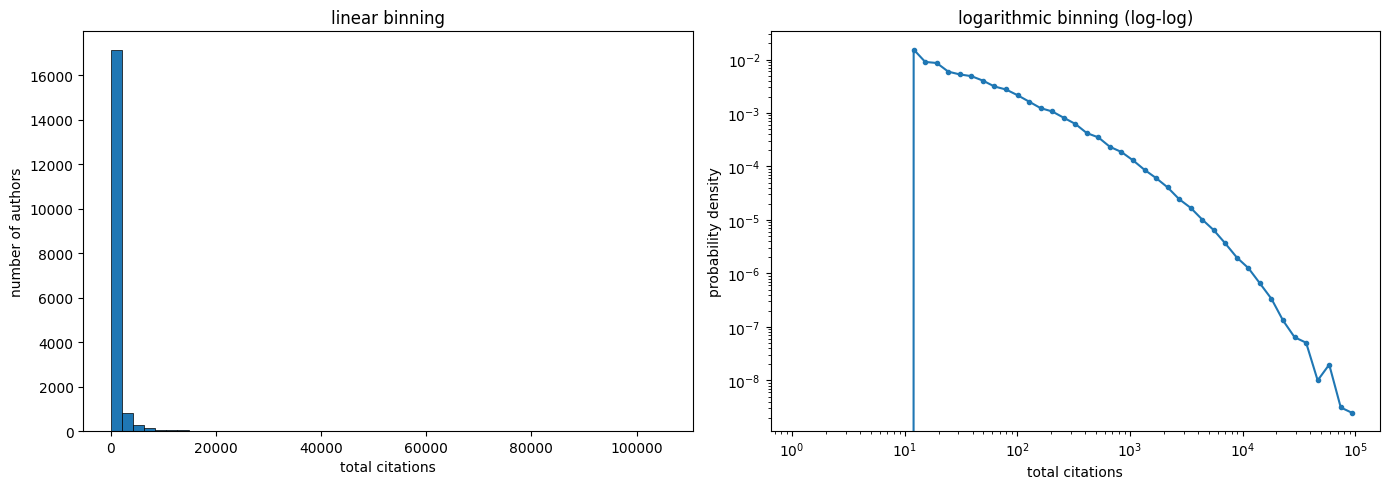

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: naive linear bins
counts, bins, _ = axes[0].hist(css_authors['total_citations'], bins=50, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('total citations')
axes[0].set_ylabel('number of authors')
axes[0].set_title('linear binning')

# right: logarithmic bins on log-log scale
log_bins = np.logspace(0, np.log10(css_authors['total_citations'].max() + 1), 50)
counts, bin_edges = np.histogram(css_authors['total_citations'][css_authors['total_citations'] > 0], bins=log_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
axes[1].plot(bin_centers, counts, 'o-', markersize=3)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('total citations')
axes[1].set_ylabel('probability density')
axes[1].set_title('logarithmic binning (log-log)')

plt.tight_layout()
plt.show()

### Task 3: Comparative Histograms by Country

In [51]:
# find top 5 countries by number of authors
top_countries = css_authors['country_code'].value_counts().head(5)
print(top_countries)

country_code
US    4974
CN    2192
DE    1113
GB    1030
IT     622
Name: count, dtype: int64


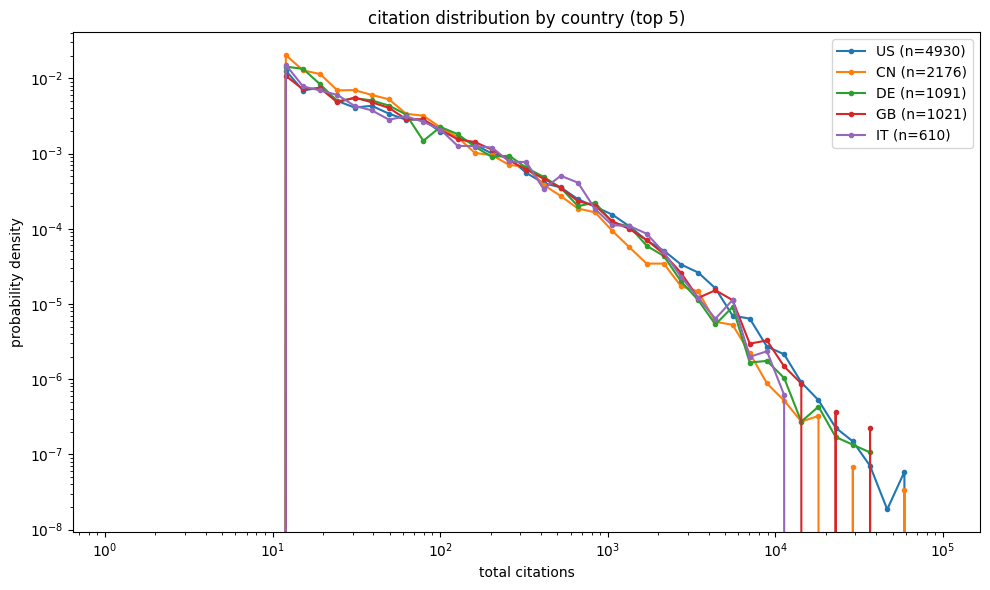

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

log_bins = np.logspace(0, np.log10(css_authors['total_citations'].max() + 1), 50)

for country in top_countries.index:
    citations = css_authors[css_authors['country_code'] == country]['total_citations']
    citations = citations[citations > 0]
    
    counts, bin_edges = np.histogram(citations, bins=log_bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, 'o-', markersize=3, label=f"{country} (n={len(citations)})")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('total citations')
ax.set_ylabel('probability density')
ax.set_title('citation distribution by country (top 5)')
ax.legend()
plt.tight_layout()
plt.show()

### Task 4: Reflection questions

**Binning choice.**
we used logarithmic binning for both tasks 2 and 3. the citation data spans several orders of magnitude (from 0 to over 100,000), so linear bins produce a useless histogram where everything piles into the first bin. logarithmic binning creates bins that are evenly spaced on a log scale, revealing the shape of the heavy-tailed distribution clearly.

**Normalization.**
we normalized the histograms (density=True) for task 3 but not task 2. normalization converts raw counts into probability density, making the area under the curve equal to 1. this is essential when comparing countries with very different numbers of authors (US has ~5000, Italy ~600) — without normalization, the US would dominate every bin simply due to its size, making comparison impossible.

**Author recognition.**
citations follow a heavy-tailed distribution across both the full dataset and individual countries — most authors have relatively few citations, while a small number have tens of thousands. this is consistent with a "rich get richer" dynamic common in academia. across countries, the distributions are remarkably similar in shape, suggesting that the overall pattern of recognition inequality is universal regardless of country.